In [1]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import glob
from scipy.io import readsav
from functools import partial
from matplotlib.colors import TwoSlopeNorm
import matplotlib.colors as mcolors
from scipy.optimize import differential_evolution, least_squares
from matplotlib.patches import ConnectionPatch

# # 在代码开头添加LaTeX设置
# import matplotlib.pyplot as plt
# plt.rcParams['text.usetex'] = True  # 启用LaTeX渲染
# plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'  # 可选：添加数学包

In [2]:
def double_cloud(lam,SL,SU,tau0L,tau0U,vL,vU,WL,WU,I0):
    lam0=6562.8
    c=299790
    tauL=tau0L*np.exp(-((lam-lam0-vL*lam0/c)**2)/WL**2)
    tauU=tau0U*np.exp(-((lam-lam0-vU*lam0/c)**2)/WU**2)
    I=I0*np.exp(-(tauL+tauU))+SL*(1-np.exp(-tauL))*np.exp(-tauU)+SU*(1-np.exp(-tauU))
    return I

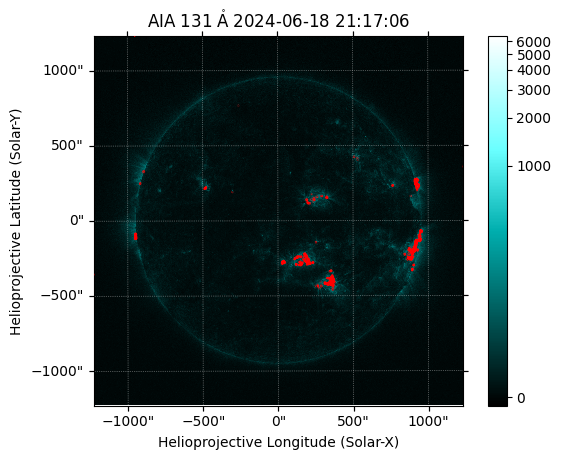

In [ ]:
import matplotlib.pyplot as plt
import sunpy.map

# 读取 FITS 数据
dir2 = r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T211708Z.131.image_lev1.fits'
aia = sunpy.map.Map(dir2)

# 创建画布
fig = plt.figure()
ax = fig.add_subplot(projection=aia)
 
# 画底图
aia.plot(axes=ax)

# 在值=1000的位置画等值线
contour = ax.contour(aia.data, levels=[200       ],
                     transform=ax.get_transform(aia.wcs),  # 保证投影正确
                     colors='red', linewidths=1.5)

plt.colorbar()
plt.show()


In [3]:
def double_cloud_vel(params, vel, Icont):
    ltauL, ltauU, vL, vU, lWl, lWu, SL, SU = params
    tau0L = np.exp(ltauL)
    tau0U = np.exp(ltauU)
    WL = np.exp(lWl)
    WU = np.exp(lWu)
    
    tauL = tau0L * np.exp(-((vel - vL)**2) / (WL**2))
    tauU = tau0U * np.exp(-((vel - vU)**2) / (WU**2))
    
    I = Icont * np.exp(-(tauL + tauU)) \
        + SL * (1 - np.exp(-tauL)) * np.exp(-tauU) \
        + SU * (1 - np.exp(-tauU))
    return I

In [4]:
#数据准备
dir=r'D:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha\RSM20240618T211711_0000_HA.fits'
rsm=fits.open(dir)
left_index=39
right_index=101
lam00 = rsm[1].header['CRVAL3'] + np.arange(rsm[1].header['NAXIS3']) * rsm[1].header['CDELT3']
lam=lam00[left_index:right_index]#±1.5A
I0=rsm[1].data[left_index:right_index,797:826,1540:1569].mean(axis=(1,2))

In [ ]:
print(lam00[39],lam00[44],lam00[54],lam00[96],lam00[101])

6561.305598407436 6561.5480186241975 6562.032859057719 6564.069188878513 6564.3116090952735


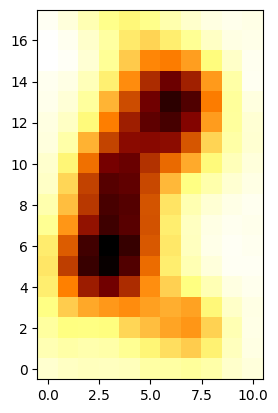

In [ ]:
stack_img=rsm[1].data[44:54,789:807,1515:1526].mean(axis=0)
plt.imshow(stack_img,cmap='afmhot',origin='lower')

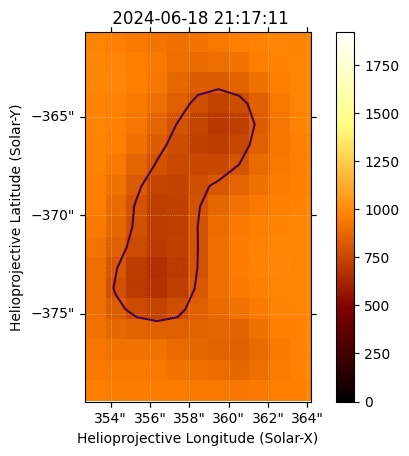

In [5]:
hawing = rsm[1].data[44:54, :, :].mean(axis=0)
coord_HIS = SkyCoord(0 * u.arcsec, 0 * u.arcsec, obstime = '2024-06-18 21:17:11', observer = 'earth', \
                     frame = frames.Helioprojective)
headerwing = sunpy.map.make_fitswcs_header(hawing, coord_HIS,
                                       reference_pixel = \
                                       [rsm[1].header['CRPIX1'], rsm[1].header['CRPIX2']] * u.pixel,
                                       scale = [0.5218 * 2, 0.5218 * 2] * u.arcsec / u.pixel,
                                       telescope = 'CHASE', instrument = 'RSM')
hawing_map = sunpy.map.Map(hawing, headerwing)

left_bottom=SkyCoord(Tx=200*u.arcsec,Ty=-520*u.arcsec,frame=hawing_map.coordinate_frame)
top_right=SkyCoord(Tx=420*u.arcsec,Ty=-300*u.arcsec,frame=hawing_map.coordinate_frame)
sub_hawing_map=hawing_map.submap(left_bottom,top_right=top_right)

# fig=plt.figure()
# ax=fig.add_subplot(projection=sub_hawing_map)
# im=sub_hawing_map.plot(axes=ax,cmap='afmhot',vmin=0, vmax = 2 * sub_hawing_map.data.mean())
# contour=ax.contour(sub_hawing_map.data,levels=[500],transform=ax.get_transform(sub_hawing_map.wcs),colors='blue')
fig=plt.figure()
jet_point4=(1515,789)
point4=hawing_map.wcs.pixel_to_world(jet_point4[0],jet_point4[1])
jet_point5=(1525,806)
point5=hawing_map.wcs.pixel_to_world(jet_point5[0],jet_point5[1])
jet_region=sub_hawing_map.submap(point4,top_right=point5)
ax3=fig.add_subplot(projection=jet_region)
im=jet_region.plot(axes=ax3,cmap='afmhot',vmin=0, vmax = 2 * sub_hawing_map.data.mean())
cbar=fig.colorbar(im,ax=ax3)
contour=ax3.contour(jet_region.data,levels=[800],transform=ax3.get_transform(jet_region.wcs))

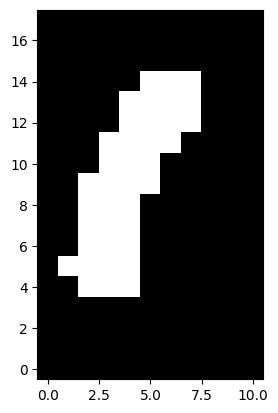

In [6]:
cs = contour
from matplotlib.path import Path
# 初始化 mask
mask = np.zeros_like(jet_region.data, dtype=bool)

# 构造像素坐标网格
ny, nx = jet_region.data.shape
X, Y = np.meshgrid(np.arange(nx), np.arange(ny))
points = np.vstack((X.flatten(), Y.flatten())).T  # (N, 2)

# 遍历所有封闭区域
for path in cs.get_paths():
    poly = Path(path.vertices)
    mask |= poly.contains_points(points).reshape(ny, nx)
# 现在 mask 就是一个布尔数组，True 表示在等值线包围区域内
plt.figure()
plt.imshow(mask, origin='lower', cmap='gray')
#plt.title("等值线区域 mask")
plt.show()

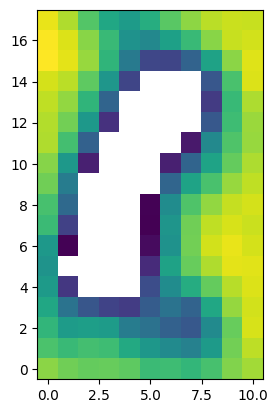

In [44]:
a1=rsm[1].data[50,789:807,1515:1526]
a2=np.ma.array(a1,mask=mask)
plt.imshow(a2,origin='lower')

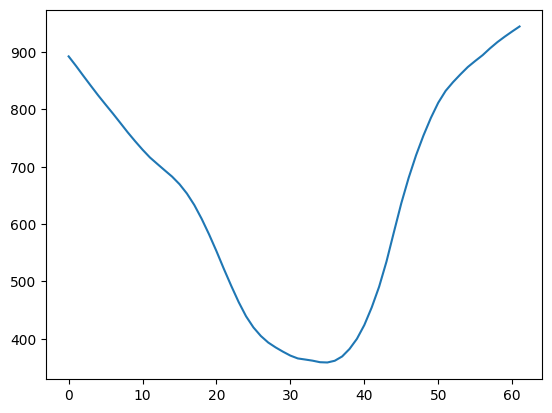

In [7]:
data_jet=rsm[1].data[left_index:right_index,789:807,1515:1526]
data_mask=np.tile(~mask,(right_index-left_index,1,1))
jet_masked=np.ma.array(data_jet,mask=data_mask)
spec_data=jet_masked.mean(axis=(1,2))
plt.plot(spec_data)

In [56]:
print(jet_masked[:,4,3])

[824 804 783 764 742 721 704 691 681 672 657 638 616 594 570 545 520 498
 476 458 446 438 430 418 407 397 389 387 383 378 376 378 383 393 404 416
 435 462 502 553 601 642 681 720 755 787 816 840 861 879 896 911]


In [57]:
print(jet_masked[0,:,:])

[[-- -- -- -- -- -- -- -- -- -- --]
 [-- -- -- -- -- -- -- -- -- -- --]
 [-- -- -- -- -- -- -- -- -- -- --]
 [-- -- -- -- -- -- -- -- -- -- --]
 [-- -- 838 824 848 -- -- -- -- -- --]
 [-- 854 779 755 792 -- -- -- -- -- --]
 [-- -- 792 754 775 -- -- -- -- -- --]
 [-- -- 851 800 807 -- -- -- -- -- --]
 [-- -- 871 809 806 -- -- -- -- -- --]
 [-- -- 868 808 806 862 -- -- -- -- --]
 [-- -- -- 823 802 842 -- -- -- -- --]
 [-- -- -- 867 821 804 802 -- -- -- --]
 [-- -- -- -- 830 777 754 793 -- -- --]
 [-- -- -- -- 850 784 733 758 -- -- --]
 [-- -- -- -- -- 815 765 799 -- -- --]
 [-- -- -- -- -- -- -- -- -- -- --]
 [-- -- -- -- -- -- -- -- -- -- --]
 [-- -- -- -- -- -- -- -- -- -- --]]


In [61]:
print((838+824+848)/3)
print(jet_masked[0,:,:].mean(axis=1))

836.6666666666666
[-- -- -- -- 836.6666666666666 795.0 773.6666666666666 819.3333333333334
 828.6666666666666 836.0 822.3333333333334 823.5 788.5 781.25 793.0 -- --
 --]


In [49]:
print(jet_masked.shape)

(52, 18, 11)


DE finished, SSE: 3634.3138880350443
SL=439.247, SU=311.578
tau0L=0.8386, tau0U=0.2646
vL=-14.599 km/s, vU=19.990 km/s
WL=55.5684 km/s, WU=9.3173 km/s
拟合误差: 4348.083913697075


Text(0.5, 0, 'Wavelength (Angstrom)')

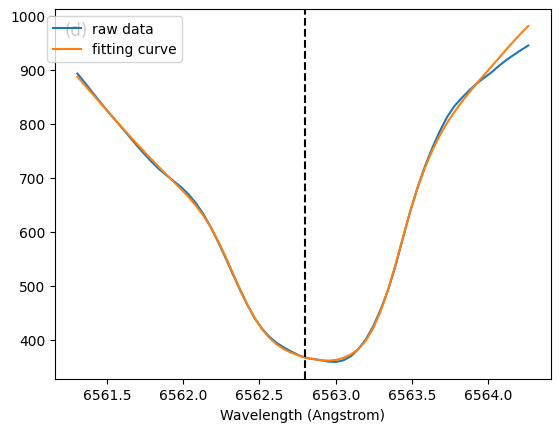

In [8]:
import numpy as np
from functools import partial
from scipy.optimize import differential_evolution, least_squares
import matplotlib.pyplot as plt

lam0 = 6562.8
c_km = 299792.458  # 光速 (km/s)
left_index=39
right_index=101
# 1. wavelength → velocity
lam=lam00[left_index:right_index]#±1.5A
vel = (lam - lam0) / lam0 * c_km  # km/s
I=spec_data
I0=rsm[1].data[left_index:right_index,797:826,1540:1569].mean(axis=(1,2))
# ===== 固定的背景连续谱强度 =====
Icont = I0  # 你之前定义的背景值，例如在平静区域测得的平均值

# 2. 双云模型（去掉 Icont 作为拟合变量）
# 参数: [ltauL, ltauU, vL, vU, lWl, lWu, SL, SU]
def double_cloud_vel(params, vel, Icont):
    ltauL, ltauU, vL, vU, lWl, lWu, SL, SU = params
    tau0L = np.exp(ltauL)
    tau0U = np.exp(ltauU)
    WL = np.exp(lWl)
    WU = np.exp(lWu)
    
    tauL = tau0L * np.exp(-((vel - vL)**2) / (WL**2))
    tauU = tau0U * np.exp(-((vel - vU)**2) / (WU**2))
    
    I = Icont * np.exp(-(tauL + tauU)) \
        + SL * (1 - np.exp(-tauL)) * np.exp(-tauU) \
        + SU * (1 - np.exp(-tauU))
    return I

# 3. 残差函数
def residuals(params, vel, I, Icont):
    return double_cloud_vel(params, vel, Icont) - I

# 4. 参数范围
# log tau: [1e-3, 1e2]
# W: [0.05, 200] km/s
Imean = np.mean(I)
lb = [
    np.log(1e-3), np.log(1e-3),   # ltauL, ltauU
    -200.0, -200.0,               # vL, vU
    np.log(0.05), np.log(0.05),   # lWl, lWu
    0.0, 0.0                       # SL, SU
]
ub = [
    np.log(1e2), np.log(1e2),
    200.0, 200.0,
    np.log(200.0), np.log(200.0),
    Imean*10, Imean*10
]
bounds = list(zip(lb, ub))

# 5. DE全局搜索
def ssq_obj(x):
    res = residuals(x, vel, I, Icont)
    return np.sum(res**2)

result_de = differential_evolution(ssq_obj, bounds, maxiter=800, popsize=15, tol=1e-6)
x_de = result_de.x
print("DE finished, SSE:", result_de.fun)

# 6. 局部精炼
lsq = least_squares(residuals, x_de, args=(vel, I, Icont),
                    bounds=(np.array(lb), np.array(ub)),
                    loss='soft_l1', f_scale=0.1,
                    x_scale='jac', max_nfev=2000)
x_opt = lsq.x

# 7. 拆解结果
ltauL, ltauU, vL, vU, lWl, lWu, SL, SU = x_opt
tau0L = np.exp(ltauL); tau0U = np.exp(ltauU)
WL = np.exp(lWl); WU = np.exp(lWu)


print(f"SL={SL:.3f}, SU={SU:.3f}")
print(f"tau0L={tau0L:.4f}, tau0U={tau0U:.4f}")
print(f"vL={vL:.3f} km/s, vU={vU:.3f} km/s")
print(f"WL={WL:.4f} km/s, WU={WU:.4f} km/s")

# 8. 作图
y_fit = double_cloud_vel(x_opt, vel, Icont)
print('拟合误差:',np.sum((I-y_fit)**2))
fig,ax=plt.subplots()
ax.plot(lam, I, label='raw data')
ax.plot(lam, y_fit, label='fitting curve')
ax.text(0.02,0.93,'(d)',color='black',transform=ax.transAxes,fontsize=12)
ax.axvline(lam0, linestyle='--',color='black')
ax.legend(bbox_to_anchor=(0.27, 1))
ax.set_xlabel('Wavelength (Angstrom)')

SL=188.77,初值是740.59,范围是[0.00,20000.00], SU=477.37,初值是740.59,范围是[0.00,20000.00]
tau0L=0.97,初值是0.20,范围是[0.00,100.00], tau0U=0.91,初值是0.20,范围是[0.00,100.00]
vL=4.19,初值是-11.00,范围是[-100.00,100.00], vU=-15.77,初值是-13.00,范围是[-150.00,100.00]
WL=0.38,初值是0.50,范围是[0.01,10.00], WU=1.22,初值是0.50,范围是[0.01,10.00]
拟合误差: 827.5778064758053


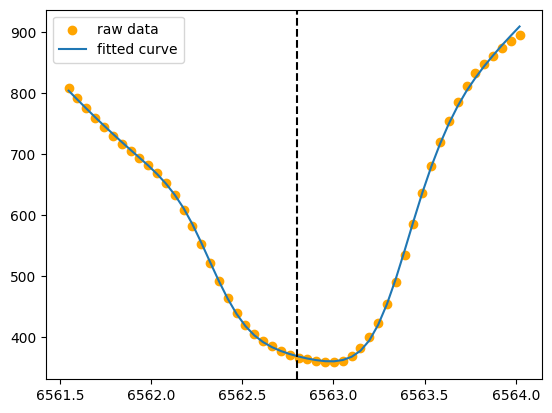

In [ ]:
#I=rsm[1].data[50:90,795,1521]
I=spec_data[5:-5]
#初值
paras2=np.zeros((3,8))
#第0列是SL_initial,min,max
paras2[0,0],paras2[1,0],paras2[2,0]=np.mean(I0),0,20000
#第1列是SU_initial,min,max
paras2[0,1],paras2[1,1],paras2[2,1]=np.mean(I0),0,20000
#第2列是\tau0L_initial,min,max
paras2[0,2],paras2[1,2],paras2[2,2]=0.2,0.001,100
#第3列是\tau0U_initial,min,max
paras2[0,3],paras2[1,3],paras2[2,3]=0.2,0.001,100
#第4列是vL_initial,min,max
paras2[0,4],paras2[1,4],paras2[2,4]=-11,-100,100
#第5列是vU_initial,min,max
paras2[0,5],paras2[1,5],paras2[2,5]=-13,-150,100
#第6列是多普勒展宽WL
paras2[0,6],paras2[1,6],paras2[2,6]=0.5,0.01,10
#第7列是多普勒展宽WU
paras2[0,7],paras2[1,7],paras2[2,7]=0.5,0.01,10


#曲线拟合
double_cloud_par=partial(double_cloud,I0=I0[5:-5])
popt2,pcov2=curve_fit(double_cloud_par,lam[5:-5],I,p0=paras2[0,:],
                    bounds=(paras2[1,:],paras2[2,:]),maxfev=2000)

#输出拟合结果
SL_fit,SU_fit,tau0L_fit,tau0U_fit,vL_fit,vU_fit,WL_fit,WU_fit=popt2
print('SL={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}], SU={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}]'.format(SL_fit,paras2[0,0],paras2[1,0],paras2[2,0],SU_fit,paras2[0,1],paras2[1,1],paras2[2,1]))
print('tau0L={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}], tau0U={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}]'.format(tau0L_fit,paras2[0,2],paras2[1,2],paras2[2,2],tau0U_fit,paras2[0,3],paras2[1,3],paras2[2,3]))
print('vL={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}], vU={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}]'.format(vL_fit,paras2[0,4],paras2[1,4],paras2[2,4],vU_fit,paras2[0,5],paras2[1,5],paras2[2,5]))
print('WL={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}], WU={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}]'.format(WL_fit,paras2[0,6],paras2[1,6],paras2[2,6],WU_fit,paras2[0,7],paras2[1,7],paras2[2,7]))

#画图看拟合效果
y_err=np.sqrt(I)
plt.scatter(lam[5:-5],I,label='raw data',color='orange')
plt.plot(lam[5:-5],double_cloud_par(lam[5:-5],*popt2),label='fitted curve')
plt.axvline(x=6562.8,linestyle='--',color='black')
plt.legend()

y_fit=double_cloud_par(lam[5:-5],*popt2)
print('拟合误差:',np.sum((I-y_fit)**2))

<ErrorbarContainer object of 3 artists>

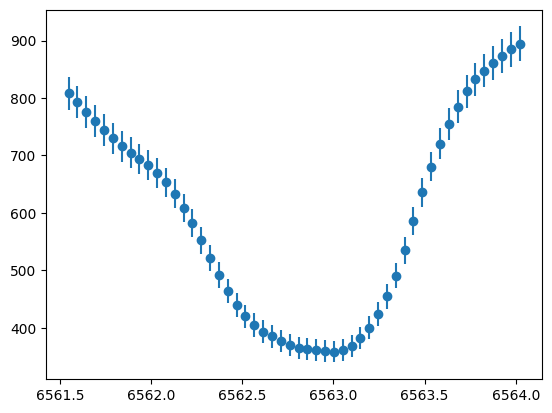

In [92]:
plt.errorbar(lam[5:-5],I,yerr=np.sqrt(I),fmt='o')

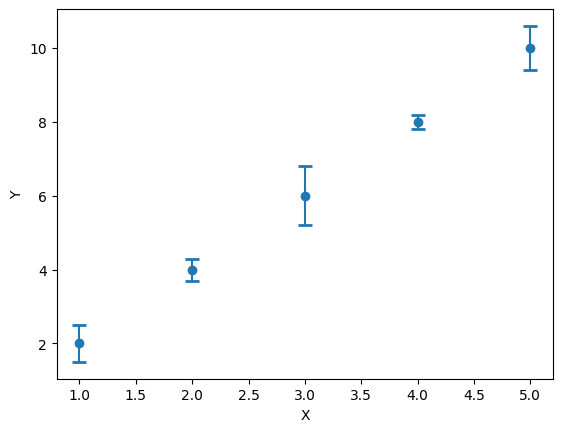

In [85]:
import matplotlib.pyplot as plt
import numpy as np

# 示例数据
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 6, 8, 10])
y_err = np.array([0.5, 0.3, 0.8, 0.2, 0.6])  # y方向的误差

plt.errorbar(x, y, yerr=y_err, fmt='o', capsize=5, capthick=2)
plt.xlabel('X')
plt.ylabel('Y')
#plt.title('带误差棒的散点图')
plt.show()

宁静区左下角的位置  y:797.58,x:1540.66
宁静区右上角的位置  y:826.32,x:1569.41
喷流点选取的位置  y:791.00,x:1520.00
喷流选取的位置  y:789.00,x:1515.00
喷流选取的位置  y:806.00,x:1525.00


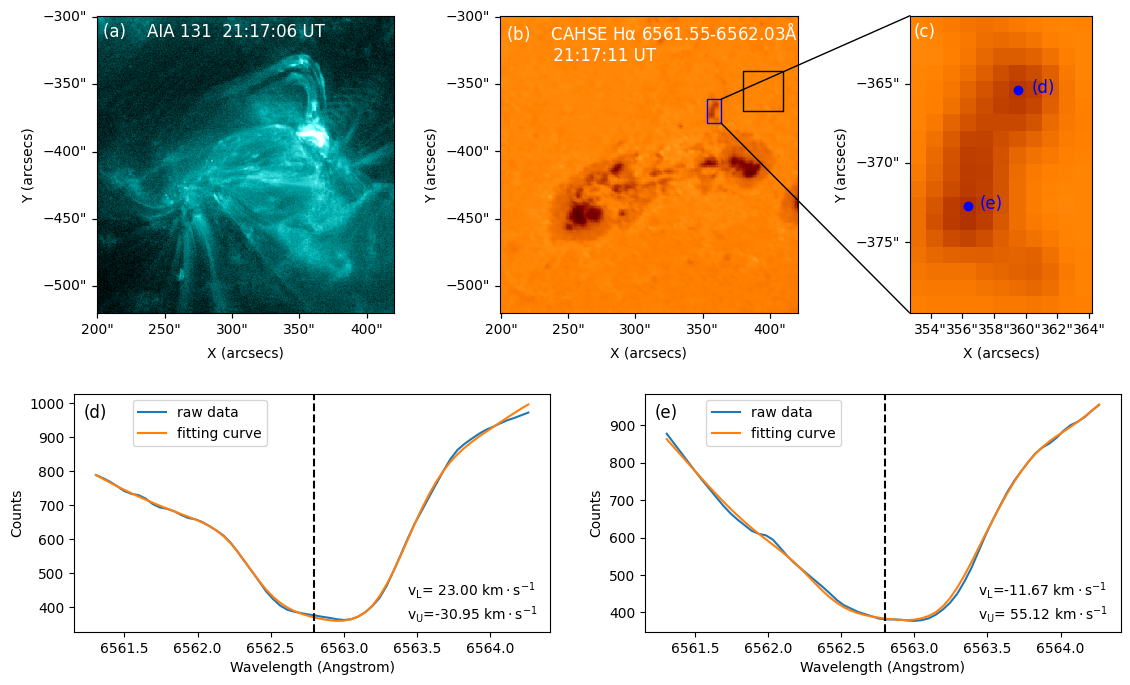

In [24]:
import matplotlib as mpl
mpl.rcParams['text.usetex'] = False

#画图
hawing = rsm[1].data[44:54, :, :].mean(axis=0)
coord_HIS = SkyCoord(0 * u.arcsec, 0 * u.arcsec, obstime = '2024-06-18 21:17:11', observer = 'earth', \
                     frame = frames.Helioprojective)
headerwing = sunpy.map.make_fitswcs_header(hawing, coord_HIS,
                                       reference_pixel = \
                                       [rsm[1].header['CRPIX1'], rsm[1].header['CRPIX2']] * u.pixel,
                                       scale = [0.5218 * 2, 0.5218 * 2] * u.arcsec / u.pixel,
                                       telescope = 'CHASE', instrument = 'RSM')
hawing_map = sunpy.map.Map(hawing, headerwing)

left_bottom=SkyCoord(Tx=200*u.arcsec,Ty=-520*u.arcsec,frame=hawing_map.coordinate_frame)
top_right=SkyCoord(Tx=420*u.arcsec,Ty=-300*u.arcsec,frame=hawing_map.coordinate_frame)
sub_hawing_map=hawing_map.submap(left_bottom,top_right=top_right)

#aia131图像
dir2=r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T211708Z.131.image_lev1.fits'
aia=sunpy.map.Map(dir2)
left_bottom=SkyCoord(Tx=200*u.arcsec,Ty=-520*u.arcsec,frame=aia.coordinate_frame)
top_right=SkyCoord(Tx=420*u.arcsec,Ty=-300*u.arcsec,frame=aia.coordinate_frame)
sub_aia=aia.submap(left_bottom,top_right=top_right)
#----------------------------------------------------------------------------------------------------------------------------

fig=plt.figure(figsize=(13.5,8))
gs=gridspec.GridSpec(2,1,hspace=0.3,height_ratios=[1,0.8])
gs_top=gridspec.GridSpecFromSubplotSpec(1,3,subplot_spec=gs[0],wspace=0.2,width_ratios=[1,1,0.7])
old_norm=sub_aia.plot_settings['norm']
old_norm.vmin=0.01
old_norm.vmax=2000
ax1=fig.add_subplot(gs_top[0],projection=sub_aia)
sub_aia.plot(axes=ax1,norm=old_norm)
#------------------------------------------------------------------------------------------------------------------
#图2
ax2=fig.add_subplot(gs_top[1],projection=sub_hawing_map)
sub_hawing_map.plot(axes=ax2,cmap = 'afmhot', vmin = 0, vmax = 2 * sub_hawing_map.data.mean())

#point1是宁静区左下角
point1=SkyCoord(Tx=380*u.arcsec,Ty=-370*u.arcsec,frame=hawing_map.coordinate_frame)
xpix1,ypix1=hawing_map.world_to_pixel(point1)
print(f'宁静区左下角的位置  y:{ypix1.value:.2f},x:{xpix1.value:.2f}')
#point2是宁静区右上角
point2=SkyCoord(Tx=410*u.arcsec,Ty=-340*u.arcsec,frame=hawing_map.coordinate_frame)
xpix2,ypix2=hawing_map.world_to_pixel(point2)
print(f'宁静区右上角的位置  y:{ypix2.value:.2f},x:{xpix2.value:.2f}')
sub_hawing_map.draw_quadrangle(point1,top_right=point2,axes=ax2,edgecolor='black')

jet_point=(1520,791)
point3=hawing_map.wcs.pixel_to_world(jet_point[0],jet_point[1])
#ax2.plot_coord(point3,marker='o',markersize=3)
xpix3,ypix3=hawing_map.world_to_pixel(point3)
print(f'喷流点选取的位置  y:{ypix3.value:.2f},x:{xpix3.value:.2f}')
#point4是喷流选取左下角
jet_point4=(1515,789)
point4=hawing_map.wcs.pixel_to_world(jet_point4[0],jet_point4[1])
xpix4,ypix4=hawing_map.world_to_pixel(point4)
print(f'喷流选取的位置  y:{ypix4.value:.2f},x:{xpix4.value:.2f}')
#point5是喷流选取右上角
jet_point5=(1525,806)
point5=hawing_map.wcs.pixel_to_world(jet_point5[0],jet_point5[1])
#point5=SkyCoord(Tx=364*u.arcsec,Ty=-363*u.arcsec,frame=hawing_map.coordinate_frame)
xpix5,ypix5=hawing_map.world_to_pixel(point5)
print(f'喷流选取的位置  y:{ypix5.value:.2f},x:{xpix5.value:.2f}')

sub_hawing_map.draw_quadrangle(point4,top_right=point5,axes=ax2,edgecolor='blue')

#------------------------------------------------------------------------------------------
#图3
jet_region=sub_hawing_map.submap(point4,top_right=point5)
ax3=fig.add_subplot(gs_top[2],projection=jet_region)
jet_region.plot(axes=ax3,cmap='afmhot',vmin=0, vmax = 2 * sub_hawing_map.data.mean())
jet_point1=(1521,802)
jet_point11=hawing_map.wcs.pixel_to_world(jet_point1[0],jet_point1[1])
ax3.plot_coord(jet_point11,marker='o',markersize=6,color='blue')

jet_point2=(1518,795)
jet_point22=hawing_map.wcs.pixel_to_world(jet_point2[0],jet_point2[1])
ax3.plot_coord(jet_point22,marker='o',markersize=6,color='blue')
#=----------------------------------------------------------------------------------------------
#乱七八糟的画图
ax_all=[ax1,ax2,ax3]
for ax in ax_all:
    #ax.set_xlabel('X (arcsecs)')
    ax.set_xlabel('X (arcsecs)',labelpad=1.2)
    ax.set_ylabel('Y (arcsecs)')
    ax.tick_params(axis='x',which='both',bottom=True,labelbottom=True,top=False,labeltop=False)
    ax.tick_params(axis='y',which='both',left=True,labelleft=True,right=False,labelright=False) 
    ax.coords[0].grid(draw_grid=False)
    ax.coords[1].grid(draw_grid=False)
    ax.set_title('')
ax_all[0].text(0.02,0.93,'(a)    AIA 131  21:17:06 UT',color='white',transform=ax_all[0].transAxes,fontsize=12)
ax_all[1].text(0.02,0.85,r'(b)    CAHSE H$\mathrm{\alpha}$ 6561.55-6562.03$\mathrm{\AA}$'+'\n         21:17:11 UT',color='white',transform=ax_all[1].transAxes,fontsize=12)
ax_all[2].text(0.02,0.93,'(c)',color='white',transform=ax_all[2].transAxes,fontsize=12)
ax_all[2].text(0.67,0.74,'(d)',color='blue',transform=ax_all[2].transAxes,fontsize=12)
ax_all[2].text(0.38,0.35,'(e)',color='blue',transform=ax_all[2].transAxes,fontsize=12)

# 右下角
xpix4, ypix4 = sub_hawing_map.world_to_pixel(point4)   # 在中间图的像素
xpix4_sub, ypix4_sub = jet_region.world_to_pixel(point4)  # 在右侧子图的像素
# 右上角
xpix5, ypix5 = sub_hawing_map.world_to_pixel(point5)   # 在中间图的像素
xpix5_sub, ypix5_sub = jet_region.world_to_pixel(point5)  # 在右侧子图的像素

con1 = ConnectionPatch(
    xyA=(xpix5.value, ypix4.value), coordsA="data", axesA=ax2,
    xyB=(-0.5,-0.5), coordsB="data", axesB=ax3,
    color="black", lw=1
)
con2 = ConnectionPatch(
    xyA=(xpix5.value, ypix5.value), coordsA="data", axesA=ax2,
    xyB=(-0.5,17.5), coordsB="data", axesB=ax3,
    color="black", lw=1
)
ax2.add_artist(con1)
ax2.add_artist(con2)

#-------------------------------------------------------------------------------------------------------------------------
gs_bottom = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[1], wspace=0.2)
ax4 = fig.add_subplot(gs_bottom[0])
lam0 = 6562.8
c_km = 299792.458  # 光速 (km/s)
left_index=39
right_index=101
# 1. wavelength → velocity
lam=lam00[left_index:right_index]#±1.5A
vel = (lam - lam0) / lam0 * c_km  # km/s
I=rsm[1].data[left_index:right_index,802,1521]
I0=rsm[1].data[left_index:right_index,797:826,1540:1569].mean(axis=(1,2))
x_opt_two=np.load('x_opt_two.npy')
y_fit = double_cloud_vel(x_opt_two[:,0], vel, I0)
ax4.plot(lam, I, label='raw data')
ax4.plot(lam, y_fit, label='fitting curve')
ax4.text(0.02,0.9,'(d)',color='black',transform=ax4.transAxes,fontsize=12)
ax4.axvline(lam0, linestyle='--',color='black')
ax4.legend(bbox_to_anchor=(0.42, 0.75))
ax4.set_xlabel('Wavelength (Angstrom)')
ax4.set_ylabel('Counts')
ax4.text(0.7,0.05,'$\mathrm{v_L} $'+'= 23.00 '+'$\mathrm{km \cdot s^{-1}}$'+'\n'+'$\mathrm{v_U}$'+'=-30.95 '+'$\mathrm{km \cdot s^{-1}}$',color='black',
         fontsize=10,transform=ax4.transAxes)
#---------------------------------------------------------------------------------------------------------------
ax5=fig.add_subplot(gs_bottom[1])
I=rsm[1].data[left_index:right_index,795,1518]
y_fit = double_cloud_vel(x_opt_two[:,1], vel, I0)
ax5.plot(lam, I, label='raw data')
ax5.plot(lam, y_fit, label='fitting curve')
ax5.text(0.02,0.9,'(e)',color='black',transform=ax5.transAxes,fontsize=12)
ax5.axvline(lam0, linestyle='--',color='black')
ax5.legend(bbox_to_anchor=(0.27, 0.75))
ax5.set_xlabel('Wavelength (Angstrom)')
ax5.set_ylabel('Counts')
ax5.text(0.7,0.05,'$\mathrm{v_L} $'+'=-11.67 '+'$\mathrm{km \cdot s^{-1}}$'+'\n'+'$\mathrm{v_U}$'+'= 55.12 '+'$\mathrm{km \cdot s^{-1}}$',color='black',
         fontsize=10,transform=ax5.transAxes)
plt.savefig(r'D:\Learning\PHD1st\magnetic_reconnecion\paper\fig3\double_cloud.pdf',format='pdf',bbox_inches='tight', pad_inches=0.1)

In [5]:
print(x_opt_two[:,0])

[-1.54763753e-01 -4.70530419e+00 -2.64914646e+01  5.10268635e+01
  4.23347299e+00  2.54976479e+00  4.49761437e+02  6.34128198e+03]


喷流点选取的位置  y:802.00,x:1521.00


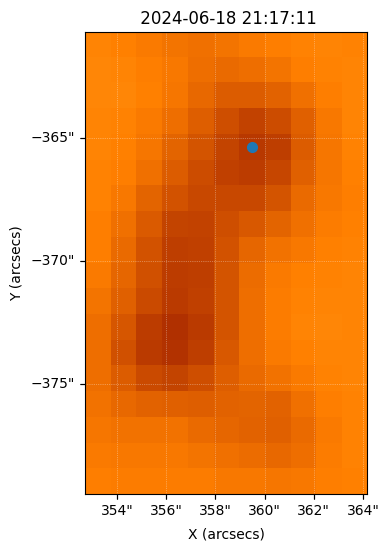

In [83]:
fig=plt.figure(figsize=(6,6))
jet_region=sub_hawing_map.submap(point4,top_right=point5)
ax=fig.add_subplot(projection=jet_region)
jet_region.plot(axes=ax,cmap='afmhot',vmin=0, vmax = 2 * sub_hawing_map.data.mean())
ax.set_xlabel('X (arcsecs)',labelpad=1.2)
#ax.set_xlabel('X(arcsecs)',labelpad=1.1)
ax.set_ylabel('Y (arcsecs)')
ax.tick_params(axis='x',which='both',bottom=True,labelbottom=True,top=False,labeltop=False)
ax.tick_params(axis='y',which='both',left=True,labelleft=True,right=False,labelright=False) 

jet_point=(1521,802)
point3=hawing_map.wcs.pixel_to_world(jet_point[0],jet_point[1])
ax.plot_coord(point3,marker='o',markersize=7)
xpix3,ypix3=hawing_map.world_to_pixel(point3)
print(f'喷流点选取的位置  y:{ypix3.value:.2f},x:{xpix3.value:.2f}')

DE finished, SSE: 3006.918754897544
SL=420.491, SU=887.460
tau0L=1.3956, tau0U=0.4472
vL=-11.665 km/s, vU=55.119 km/s
WL=49.1243 km/s, WU=13.8705 km/s


Text(0.5, 0, 'Wavelength (Angstrom)')

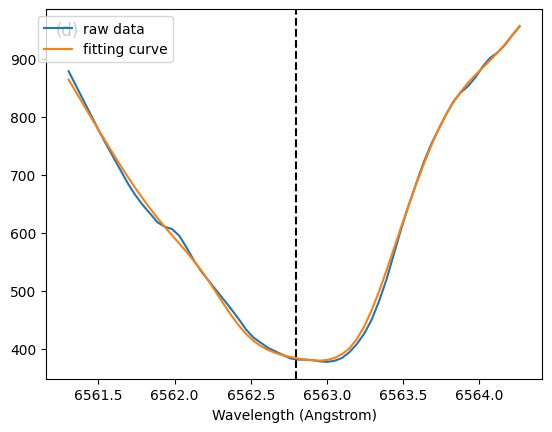

In [150]:
import numpy as np
from functools import partial
from scipy.optimize import differential_evolution, least_squares
import matplotlib.pyplot as plt

lam0 = 6562.8
c_km = 299792.458  # 光速 (km/s)
left_index=39
right_index=101
# 1. wavelength → velocity
lam=lam00[left_index:right_index]#±1.5A
vel = (lam - lam0) / lam0 * c_km  # km/s
I=rsm[1].data[left_index:right_index,795,1518]
I0=rsm[1].data[left_index:right_index,797:826,1540:1569].mean(axis=(1,2))
# ===== 固定的背景连续谱强度 =====
Icont = I0  # 你之前定义的背景值，例如在平静区域测得的平均值

# 2. 双云模型（去掉 Icont 作为拟合变量）
# 参数: [ltauL, ltauU, vL, vU, lWl, lWu, SL, SU]
def double_cloud_vel(params, vel, Icont):
    ltauL, ltauU, vL, vU, lWl, lWu, SL, SU = params
    tau0L = np.exp(ltauL)
    tau0U = np.exp(ltauU)
    WL = np.exp(lWl)
    WU = np.exp(lWu)
    
    tauL = tau0L * np.exp(-((vel - vL)**2) / (WL**2))
    tauU = tau0U * np.exp(-((vel - vU)**2) / (WU**2))
    
    I = Icont * np.exp(-(tauL + tauU)) \
        + SL * (1 - np.exp(-tauL)) * np.exp(-tauU) \
        + SU * (1 - np.exp(-tauU))
    return I

# 3. 残差函数
def residuals(params, vel, I, Icont):
    return double_cloud_vel(params, vel, Icont) - I

# 4. 参数范围
# log tau: [1e-3, 1e2]
# W: [0.05, 200] km/s
Imean = np.mean(I)
lb = [
    np.log(1e-3), np.log(1e-3),   # ltauL, ltauU
    -200.0, -200.0,               # vL, vU
    np.log(0.05), np.log(0.05),   # lWl, lWu
    0.0, 0.0                       # SL, SU
]
ub = [
    np.log(1e2), np.log(1e2),
    200.0, 200.0,
    np.log(200.0), np.log(200.0),
    Imean*10, Imean*10
]
bounds = list(zip(lb, ub))

# 5. DE全局搜索
def ssq_obj(x):
    res = residuals(x, vel, I, Icont)
    return np.sum(res**2)

result_de = differential_evolution(ssq_obj, bounds, maxiter=800, popsize=15, tol=1e-6)
x_de = result_de.x
print("DE finished, SSE:", result_de.fun)

# 6. 局部精炼
lsq = least_squares(residuals, x_de, args=(vel, I, Icont),
                    bounds=(np.array(lb), np.array(ub)),
                    loss='soft_l1', f_scale=0.1,
                    x_scale='jac', max_nfev=2000)
x_opt = lsq.x

# 7. 拆解结果
ltauL, ltauU, vL, vU, lWl, lWu, SL, SU = x_opt
tau0L = np.exp(ltauL); tau0U = np.exp(ltauU)
WL = np.exp(lWl); WU = np.exp(lWu)


print(f"SL={SL:.3f}, SU={SU:.3f}")
print(f"tau0L={tau0L:.4f}, tau0U={tau0U:.4f}")
print(f"vL={vL:.3f} km/s, vU={vU:.3f} km/s")
print(f"WL={WL:.4f} km/s, WU={WU:.4f} km/s")

# 8. 作图
y_fit = double_cloud_vel(x_opt, vel, Icont)
fig,ax=plt.subplots()
ax.plot(lam, I, label='raw data')
ax.plot(lam, y_fit, label='fitting curve')
ax.text(0.02,0.93,'(d)',color='black',transform=ax.transAxes,fontsize=12)
ax.axvline(lam0, linestyle='--',color='black')
ax.legend(bbox_to_anchor=(0.27, 1))
ax.set_xlabel('Wavelength (Angstrom)')

In [9]:
x_opt_two[:,0]=x_opt
print(x_opt_two)

[[-2.16343748e+00  3.33341216e-01]
 [-1.40214314e-01 -8.04823679e-01]
 [ 2.30040977e+01 -1.16646286e+01]
 [-3.09470820e+01  5.51187097e+01]
 [ 2.51726982e+00  3.89435403e+00]
 [ 4.13009971e+00  2.62976711e+00]
 [ 3.79006786e-25  4.20490829e+02]
 [ 4.60395250e+02  8.87460010e+02]]


In [10]:
np.save('x_opt_two.npy', x_opt_two)

In [151]:
x_opt2=x_opt

DE finished, SSE: 2410.192327406343
SL=0.000, SU=460.395
tau0L=0.1149, tau0U=0.8692
vL=23.004 km/s, vU=-30.947 km/s
WL=12.3947 km/s, WU=62.1841 km/s


Text(0.5, 0, 'Wavelength (Angstrom)')

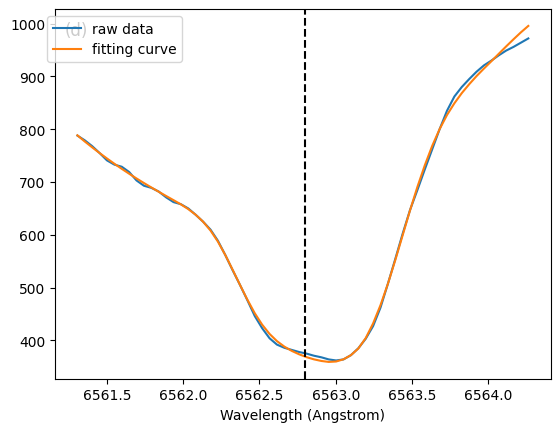

In [7]:
import numpy as np
from functools import partial
from scipy.optimize import differential_evolution, least_squares
import matplotlib.pyplot as plt

lam0 = 6562.8
c_km = 299792.458  # 光速 (km/s)
left_index=39
right_index=101
# 1. wavelength → velocity
lam=lam00[left_index:right_index]#±1.5A
vel = (lam - lam0) / lam0 * c_km  # km/s
I=rsm[1].data[left_index:right_index,802,1521]
I0=rsm[1].data[left_index:right_index,797:826,1540:1569].mean(axis=(1,2))
# ===== 固定的背景连续谱强度 =====
Icont = I0  # 你之前定义的背景值，例如在平静区域测得的平均值

# 2. 双云模型（去掉 Icont 作为拟合变量）
# 参数: [ltauL, ltauU, vL, vU, lWl, lWu, SL, SU]
def double_cloud_vel(params, vel, Icont):
    ltauL, ltauU, vL, vU, lWl, lWu, SL, SU = params
    tau0L = np.exp(ltauL)
    tau0U = np.exp(ltauU)
    WL = np.exp(lWl)
    WU = np.exp(lWu)
    
    tauL = tau0L * np.exp(-((vel - vL)**2) / (WL**2))
    tauU = tau0U * np.exp(-((vel - vU)**2) / (WU**2))
    
    I = Icont * np.exp(-(tauL + tauU)) \
        + SL * (1 - np.exp(-tauL)) * np.exp(-tauU) \
        + SU * (1 - np.exp(-tauU))
    return I

# 3. 残差函数
def residuals(params, vel, I, Icont):
    return double_cloud_vel(params, vel, Icont) - I

# 4. 参数范围
# log tau: [1e-3, 1e2]
# W: [0.05, 200] km/s
Imean = np.mean(I)
lb = [
    np.log(1e-3), np.log(1e-3),   # ltauL, ltauU
    -200.0, -200.0,               # vL, vU
    np.log(0.05), np.log(0.05),   # lWl, lWu
    0.0, 0.0                       # SL, SU
]
ub = [
    np.log(1e2), np.log(1e2),
    200.0, 200.0,
    np.log(200.0), np.log(200.0),
    Imean*10, Imean*10
]
bounds = list(zip(lb, ub))

# 5. DE全局搜索
def ssq_obj(x):
    res = residuals(x, vel, I, Icont)
    return np.sum(res**2)

result_de = differential_evolution(ssq_obj, bounds, maxiter=800, popsize=15, tol=1e-6)
x_de = result_de.x
print("DE finished, SSE:", result_de.fun)

# 6. 局部精炼
lsq = least_squares(residuals, x_de, args=(vel, I, Icont),
                    bounds=(np.array(lb), np.array(ub)),
                    loss='soft_l1', f_scale=0.1,
                    x_scale='jac', max_nfev=2000)
x_opt = lsq.x

# 7. 拆解结果
ltauL, ltauU, vL, vU, lWl, lWu, SL, SU = x_opt
tau0L = np.exp(ltauL); tau0U = np.exp(ltauU)
WL = np.exp(lWl); WU = np.exp(lWu)


print(f"SL={SL:.3f}, SU={SU:.3f}")
print(f"tau0L={tau0L:.4f}, tau0U={tau0U:.4f}")
print(f"vL={vL:.3f} km/s, vU={vU:.3f} km/s")
print(f"WL={WL:.4f} km/s, WU={WU:.4f} km/s")

# 8. 作图
y_fit = double_cloud_vel(x_opt, vel, Icont)
fig,ax=plt.subplots()
ax.plot(lam, I, label='raw data')
ax.plot(lam, y_fit, label='fitting curve')
ax.text(0.02,0.93,'(d)',color='black',transform=ax.transAxes,fontsize=12)
ax.axvline(lam0, linestyle='--',color='black')
ax.legend(bbox_to_anchor=(0.27, 1))
ax.set_xlabel('Wavelength (Angstrom)')

In [8]:
print(x_opt)

[-2.16343748e+00 -1.40214314e-01  2.30040977e+01 -3.09470820e+01
  2.51726982e+00  4.13009971e+00  3.79006786e-25  4.60395250e+02]


In [143]:
x_opt1=x_opt

In [156]:
x_opt_two=np.column_stack((x_opt1,x_opt2))
print(x_opt_two)
x_opt_two=np.save('x_opt_two.npy',x_opt_two)

[[-1.54763753e-01  3.33341216e-01]
 [-4.70530419e+00 -8.04823679e-01]
 [-2.64914646e+01 -1.16646286e+01]
 [ 5.10268635e+01  5.51187097e+01]
 [ 4.23347299e+00  3.89435403e+00]
 [ 2.54976479e+00  2.62976711e+00]
 [ 4.49761437e+02  4.20490829e+02]
 [ 6.34128198e+03  8.87460010e+02]]


In [ ]:

lam0 = 6562.8
c_km = 299792.458  # 光速 (km/s)

# 1. wavelength → velocity
vel = (lam - lam0) / lam0 * c_km  # km/s

# ===== 固定的背景连续谱强度 =====
Icont = I0  # 你之前定义的背景值，例如在平静区域测得的平均值

# 2. 双云模型（去掉 Icont 作为拟合变量）
# 参数: [ltauL, ltauU, vL, vU, lWl, lWu, SL, SU]
def double_cloud_vel(params, vel, Icont):
    ltauL, ltauU, vL, vU, lWl, lWu, SL, SU = params
    tau0L = np.exp(ltauL)
    tau0U = np.exp(ltauU)
    WL = np.exp(lWl)
    WU = np.exp(lWu)
    
    tauL = tau0L * np.exp(-((vel - vL)**2) / (WL**2))
    tauU = tau0U * np.exp(-((vel - vU)**2) / (WU**2))
    
    I = Icont * np.exp(-(tauL + tauU)) \
        + SL * (1 - np.exp(-tauL)) * np.exp(-tauU) \
        + SU * (1 - np.exp(-tauU))
    return I

# 3. 残差函数
def residuals(params, vel, I, Icont):
    return double_cloud_vel(params, vel, Icont) - I

# 4. 参数范围
# log tau: [1e-3, 1e2]
# W: [0.05, 200] km/s
Imean = np.mean(I)
lb = [
    np.log(1e-3), np.log(1e-3),   # ltauL, ltauU
    -200.0, -200.0,               # vL, vU
    np.log(0.05), np.log(0.05),   # lWl, lWu
    0.0, 0.0                       # SL, SU
]
ub = [
    np.log(1e2), np.log(1e2),
    200.0, 200.0,
    np.log(200.0), np.log(200.0),
    Imean*10, Imean*10
]
bounds = list(zip(lb, ub))
paras_fit=np.zeros((18,11,8))
SSE=np.zeros((18,11))
# 5. DE全局搜索
def ssq_obj(x):
    res = residuals(x, vel, I, Icont)
    return np.sum(res**2)
for i in range(789,807):
    for j in range(1515,1526):
        I=rsm[1].data[left_index:right_index,i,j]
        result_de = differential_evolution(ssq_obj, bounds, maxiter=800, popsize=15, tol=1e-6)
        x_de = result_de.x
        print("DE finished, SSE:", result_de.fun)
        SSE[i-789,j-1515]=result_de.fun

        # 6. 局部精炼
        lsq = least_squares(residuals, x_de, args=(vel, I, Icont),
                            bounds=(np.array(lb), np.array(ub)),
                            loss='soft_l1', f_scale=0.1,
                            x_scale='jac', max_nfev=2000)
        x_opt = lsq.x

        # 7. 拆解结果
        ltauL, ltauU, vL, vU, lWl, lWu, SL, SU =  x_opt
        tau0L = np.exp(ltauL); tau0U = np.exp(ltauU)
        WL = np.exp(lWl); WU = np.exp   (lWu)
        paras_fit[i-789,j-1515,:]=[tau0L, tau0U, vL, vU, WL, WU, SL, SU]


DE finished, SSE: 859.099928564708
DE finished, SSE: 1327.3626726437913
DE finished, SSE: 1508.115505699393
DE finished, SSE: 3547.6506762347635
DE finished, SSE: 2468.174671599645
DE finished, SSE: 3146.7061941723373
DE finished, SSE: 2529.807136414641
DE finished, SSE: 6237.660605436126
DE finished, SSE: 7682.087336367404
DE finished, SSE: 2762.939145955986
DE finished, SSE: 641.2016332593105
DE finished, SSE: 1155.4305074814497
DE finished, SSE: 1285.139120084393
DE finished, SSE: 801.0031090707434
DE finished, SSE: 1007.2442437512025
DE finished, SSE: 2344.6709663638717
DE finished, SSE: 1860.5723868541927
DE finished, SSE: 4081.2511427313984
DE finished, SSE: 3499.3142207901965
DE finished, SSE: 1268.45109382736
DE finished, SSE: 1084.673014654775
DE finished, SSE: 703.5294373417345
DE finished, SSE: 1507.7494685871422
DE finished, SSE: 974.3239444897941
DE finished, SSE: 555.8985883212077
DE finished, SSE: 718.5508945230305
DE finished, SSE: 1142.434703554681
DE finished, SSE: 10

In [21]:
paras_fit=np.load('double_cloud_param.npy')
SSE=np.load('double_cloud_SSE.npy')

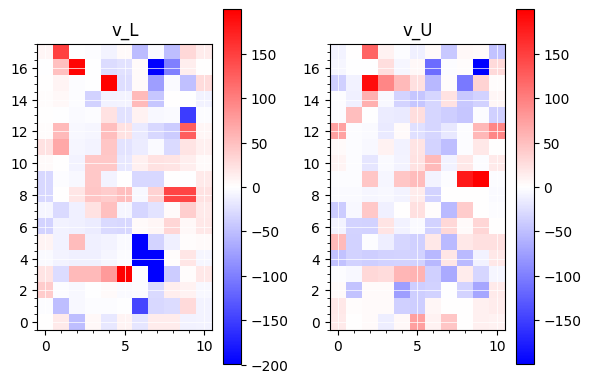

In [85]:
fig, (ax1,ax3) = plt.subplots(1, 2, figsize=(6,4))

# 第一个子图
im1 = ax1.imshow(paras_fit[:,:,2], cmap='bwr', origin='lower')
plt.colorbar(im1, ax=ax1)
ax1.minorticks_on()
ax1.grid(True, color='white', linestyle='-', linewidth=0.5)
ax1.set_title('v_L')
#ax1.scatter(1518-1515,794-789,color='r')
im3=ax3.imshow(paras_fit[:,:,3],cmap='bwr',origin='lower')
#ax3.scatter(1518-1515,794-789,color='r')
plt.colorbar(im3,ax=ax3)
ax3.minorticks_on()
ax3.grid(True, color='white', linestyle='-', linewidth=0.5)
ax3.set_title('v_U')
plt.tight_layout()
plt.show()

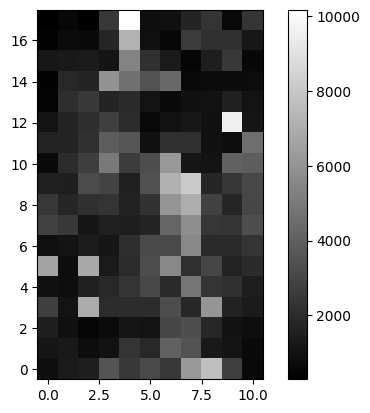

In [ ]:
#SSE[3,3:6]=2000
plt.imshow(SSE,origin='lower',cmap='gray')
plt.colorbar()

In [25]:
np.save('double_cloud_param.npy',paras_fit)

In [27]:
np.save('double_cloud_SSE.npy',SSE)